# CS148a Project 4 (FM) Starter


## 1. Getting Set up (Run the hidden cells)

In [2]:
import random
IMAGE_SIZE = 228

In [3]:
import gdown
import os
import zipfile
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATASET_URLS = [
    # Copies with resized images to max (512, _) or (_, 512) dimension
    'https://drive.google.com/uc?export=download&id=1otCXQ5BfPeyGJgK3XS-kv5iAJphhCRvJ',
    'https://drive.google.com/uc?export=download&id=1ogM03UInKocJSD219s5peyqj4vMY94ob',
    'https://drive.google.com/uc?export=download&id=1ngRkIXsf4rZ-NFG1Q1cQB61X1qUKEYRx',
    'https://drive.google.com/uc?export=download&id=1n53ZL8tUvAf3PW7qLAwFh8yRHKy0CXX9',
    'https://drive.google.com/uc?export=download&id=1n3axJY9LmhZQxLsZUN6gcdIkTwuf5Ofg',
    'https://drive.google.com/uc?export=download&id=1g4kUzGMtUgXlPlB-StZ-rkxV9_3S4ReY',
    'https://drive.google.com/uc?export=download&id=1aR2-zsys1zuERGtpaqBqI1uV0XjGzYsc',
    'https://drive.google.com/uc?export=download&id=1NESAyQ7QEegcpbrKuN0EsIsoynEIsdP9',
    'https://drive.google.com/uc?export=download&id=1CwDEoSrxcNw_U4DX6JBy4ed4W1wYbSRp',
    'https://drive.google.com/uc?export=download&id=1ov6EFLfXfPAXW2BSXHaXdN2cpl9Tsg23',

    # Old url (full image sizes)
    'https://drive.google.com/uc?export=download&id=1_gIar-Q89tWll-dnJUE077UujzAVMPxQ',
]

HUGGINGFACE_DATASET = 'EE148-project/MNIST-in-the-world'

def download_and_extract(
    url: str = 'https://drive.google.com/uc?id=1_gIar-Q89tWll-dnJUE077UujzAVMPxQ',
    output_zip_path: str = 'data/dataset.zip',
    force_download: bool = False
) -> str:
    os.makedirs(os.path.dirname(output_zip_path), exist_ok=True)
    if not os.path.exists(output_zip_path) or force_download:
        gdown.download(url, output_zip_path, quiet=False)
    data_dir = output_zip_path.replace('.zip', '')
    with zipfile.ZipFile(output_zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print(f"Extracted to {data_dir}")
    return data_dir

def load_data_from_huggingface(dataset_name: str = HUGGINGFACE_DATASET) -> list[dict]:
    from datasets import load_dataset
    print(f"Downloading dataset from HuggingFace: {dataset_name}")
    ds = load_dataset(dataset_name, split='train', streaming=True)
    dataset = []
    for item in ds:
        dataset.append({
            'img': item['image'],
            'label': item['label'],
            'path': None,
        })
    print(f"Loaded {len(dataset)} images from HuggingFace")
    return dataset

def load_data(data_dir: str) -> list[dict]:
    dataset: list[dict] = []
    filenames = [f for f in os.listdir(data_dir) if f.endswith('.jpg')]
    for f in filenames:
        path = os.path.join(data_dir, f)
        shrink = transforms.Compose([transforms.Resize((IMAGE_SIZE , IMAGE_SIZE ))])
        img = shrink(Image.open(path))
        label = int(path.split('_')[-1].replace('.jpg', '').replace('label', ''))
        setting = path.split('_')[0]
        dataset.append({
            'img': img,
            'label': label,
            'setting': setting,
        })
    return dataset

def download_and_load_data(
    urls: list[str] = DATASET_URLS,
    output_zip_path: str = 'data/dataset.zip',
) -> list[dict]:
    for url in urls:
        try:
            data_dir = download_and_extract(url, output_zip_path, force_download=False)
            return load_data(data_dir)
        except Exception as e:
            print(f"Google Drive download failed ({type(e).__name__}): {e}")

    print("All Google Drive links failed. Falling back to HuggingFace...")
    return load_data_from_huggingface()

# data: list[dict] = download_and_load_data()

In [4]:
data = load_data("data/dataset")

In [5]:
images = []
labels = []
settings = []
for item in data:
    images.append(item['img'])
    labels.append(item['label'])
    settings.append(item['setting'])

### The above code loaded in some variables for you.

- `images: list[PIL.JpegImagePlugin.JpegImageFile]`
- `labels: list[int]`

Let's take a look!

idx = 0, label = 3


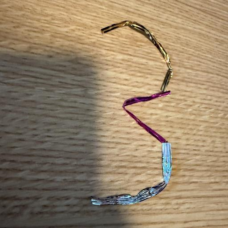

idx = 1, label = 8


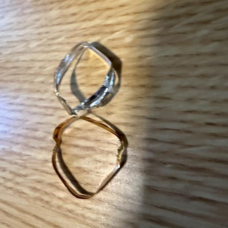

idx = 2, label = 3


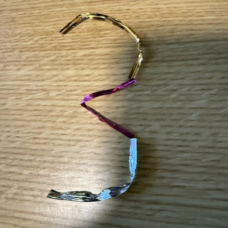

In [6]:
import numpy as np

# Display random data points
for i in [0, 1, 2]:
    print(f"idx = {i}, label = {labels[i]}")
    display(images[i])

### If you are running this on Google Colab, look to the upper right corner. Make sure you are using a GPU runtime.

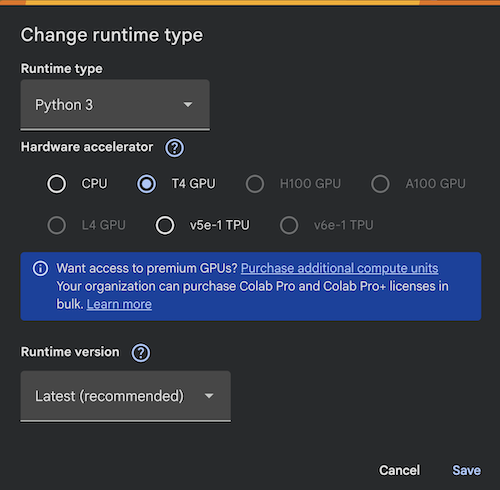

### You can reach this menu by clicking on "Runtime" (upper left) and "Change Runtime".
Let's make sure your device prints "cuda". If it says "cpu", your runtime needs to change!

In [7]:
import torch

cuda_available = torch.cuda.is_available()
mps_available = torch.backends.mps.is_available()  # macOS ARM chips
DEVICE = torch.device("cuda" if cuda_available else ("mps" if mps_available else "cpu"))
print("Using device:", DEVICE)

Using device: cuda


NOTE: If you are running this notebook locally and if you have a Mac device with an ARM chip (M1, M2, etc), you should be able to run using the built-in GPU. You will need to install a different version of torch: https://developer.apple.com/metal/pytorch/

### If you are running this notebook on Google Cloud, follow [these instructions](https://docs.google.com/document/d/1DUj8zz7v2JOfNMsxytD9mMYGTIH4eE41nUwbwMPxA1M/edit?usp=sharing) to get a GPU runtime setup.

## 2. Building your Dataloader (same as CNN)

In [8]:
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F

In [9]:
class dummy_MNIST(Dataset):
    def __init__(
        self,
        images: list[Image.Image],
        labels: list[int],
        transform: transforms.transforms.Compose = None
    ):
        """
        Dummy MNIST dataset class.

        Args:
            images: list of PIL.Image objects
            labels: list of ints representing the digit in each image
            transform: optional torchvision transform
        """

        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = images[idx]
        label = labels[idx]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


### Now let's instantiate this basic dataset.

Note that your model will throw an error if you just use the transforms available to you. We want to make sure all images are the same size.

In [10]:
transform = transforms.Compose([
    # ... any more you want to add?
    # transforms.RandomResizedCrop(
    #     IMAGE_SIZE, 
    #     scale=(0.85, 1.0),        # zoom range    # slight aspect ratio jitter
    # ),
    # transforms.RandomRotation(
    #     degrees=15              # rotate between -15 and +15 degrees
    # ),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
])


clip_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std=(0.26862954, 0.26130258, 0.27577711)
    )
])
dataset = dummy_MNIST(
    images=images,
    labels=labels,
    transform=clip_transform
)


### Before we  train our model, we want to set aside a portion to use for validation.

### Now let's define the dataloader.

In [11]:
# train_fraction = # ... # how much of your data do you want to use for training, and how much do you want to save for validation?
# num_samples = len(dataset)

# num_train = int(train_fraction * num_samples)
# num_val = num_samples - num_train


# train_dataset, val_dataset = random_split(
#     dataset,
#     [num_train, num_val],
#     generator=torch.Generator().manual_seed(42)
# )
train_fraction = 0.8
all_settings = list(set(settings))
random.shuffle(all_settings)
num_train_settings = int(train_fraction * len(all_settings))
train_settings, val_settings = set(all_settings[:num_train_settings]), set(all_settings[num_train_settings:])

train_images = [images[i] for i in range(len(images)) if settings[i] in train_settings]
train_labels = [labels[i] for i in range(len(images)) if settings[i] in train_settings]

val_images = [images[i] for i in range(len(images)) if settings[i] in val_settings]
val_labels = [labels[i] for i in range(len(images)) if settings[i] in val_settings]

# train_transform =  transforms.Compose([
#     transforms.Grayscale(num_output_channels=3),
#      transforms.Lambda(lambda img: img.convert("RGB")),
#     transforms.ToTensor(),
# ])


batch_size = 32

train_loader = DataLoader(
    dummy_MNIST(images = train_images, labels= train_labels, transform= clip_transform),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dummy_MNIST(images = val_images, labels= val_labels, transform= clip_transform),
    batch_size=batch_size,
    shuffle=True
)

### A note before we move on to the next section: keep in mind that you are allowed to:
- impute any data points you think are harming your training, for whatever reason
- re-balance your data if you find that the training data is skewed towards more of one class label than another (i.e., by throwing out samples that are abundant, augmenting lacking samples, etc.)
- Augment the images in whatever manner you find reasonable (is random cropping reasonable? Is rotation?)
- implement whatever training tips and tricks you learned in lecture (e.g., early stopping, regularization, ...)
- Visualize training while it is ongoing to debug if loss is even going down
- etc.

# Part 1: CLIP zero-shot classification

### Using CLIP embeddings:

In [12]:
from transformers import CLIPProcessor, CLIPModel
import torch

# Loading CLIP
print("Loading CLIP B32...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", use_fast=False)
print("CLIP B32 loaded successfully.")

#make sure you freeze the clip model

clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False


Loading CLIP B32...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP B32 loaded successfully.


### Let's try zero-shot classifying with CLIP.

In [13]:
clip_model = clip_model.to(DEVICE)
clip_model.eval()

classnames = [str(i) for i in range(10)]
prompts = [f"A picture of {c}" for c in classnames]

with torch.no_grad():
    text_inputs = clip_processor(text=prompts, return_tensors="pt", padding=True)
    text_inputs = {k: v.to(DEVICE) for k, v in text_inputs.items()}

    text_outputs = clip_model.text_model(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs["attention_mask"]
    )
    text_feats = clip_model.text_projection(text_outputs.pooler_output)
    text_feats = F.normalize(text_feats, dim=-1)

    logit_scale = clip_model.logit_scale.exp()

correct, total = 0, 0

for X, y in train_loader:
    inputs = clip_processor(images=X, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(DEVICE)
    y = y.to(DEVICE)

    with torch.no_grad():
        vision_outputs = clip_model.vision_model(pixel_values=pixel_values)
        img_feats = clip_model.visual_projection(vision_outputs.pooler_output)
        img_feats = F.normalize(img_feats, dim=-1)

        logits = logit_scale * (img_feats @ text_feats.T)
        preds = logits.argmax(dim=-1)

    correct += (preds == y).sum().item()
    total += y.numel()

print(f"zero-shot top-1 acc: {correct/total:.4f} ({correct}/{total})")

ValueError: The image to be converted to a PIL image contains values outside the range [0, 1], got [-1.3543097972869873, 1.5344343185424805] which cannot be converted to uint8.

In [19]:
import torch.nn.functional as F

clip_model = clip_model.to(DEVICE)
clip_model.eval()

classnames = [str(i) for i in range(10)]
prompts = [f"A photo of a {c}" for c in classnames]

with torch.no_grad():
    text_inputs = clip_processor(text=prompts, return_tensors="pt", padding=True)
    text_inputs = {k: v.to(DEVICE) for k, v in text_inputs.items()}

    text_feats = clip_model.get_text_features(**text_inputs)
    if not isinstance(text_feats, torch.Tensor):
        # fallback in case your transformers version returns a model output
        text_feats = text_feats.pooler_output if hasattr(text_feats, "pooler_output") else text_feats[1]

    logit_scale = clip_model.logit_scale.exp()

correct, total = 0, 0

for X, y in train_loader:
    inputs = clip_processor(images=X, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(DEVICE)
    y = y.to(DEVICE)

    with torch.no_grad():
        img_feats = clip_model.get_image_features(pixel_values=pixel_values)
        if not isinstance(img_feats, torch.Tensor):
            img_feats = img_feats.pooler_output if hasattr(img_feats, "pooler_output") else img_feats[1]

        logits = logit_scale * (img_feats @ text_feats.T)
        preds = logits.argmax(dim=-1)

    correct += (preds == y).sum().item()
    total += y.numel()

print(f"zero-shot top-1 acc: {correct/total:.4f} ({correct}/{total})")

zero-shot top-1 acc: 0.0988 (814/8239)


# Part 2: CLIP w/ a downstream classifier

### Now let's write a downstream classifier.

In [39]:
# the classifier here is an MLP, but feel free to use something else.

class dummy_MLP(nn.Module):
    def __init__(self, FM_feature_dim = 32, num_classes = 10):
        super().__init__()
        self.fc1 = nn.Linear(FM_feature_dim, 128) #you can choose your hidden dimensions!
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, num_classes)

    def forward(self, x):
        # x is expected to be the CLIP image features
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x


### Let's instantiate the model.

In [ ]:
qwen_model = dummy_MLP(FM_feature_dim = 32, num_classes= 10) # what is the embedding dimension for CLIP image encoder?
qwen_model = qwen_model.to(DEVICE)

criterion = # ... # what might be a good loss function?




## Train your model.
Note that, depending on whether your model is on CUDA or CPU, you may have to tweak your dataloader.

**You also probably want to train more than 1 epoch. Update the code to put the training loop inside of a function, so you can call the training function with the desired hyperparameters (learning rate, number of epochs, model layers, etc.)**

**For the visualization part, you will want to have kept a log of your training loss, validation performance under different hyperparams, etc.**

In [ ]:
optimizer = torch.optim.Adam(qwen_model.parameters(), lr= ...) # what might be a good learning rate?
                             # feel free to change the optimizer around.
train_loss_dict = dict()

In [58]:
from tqdm import tqdm
def train_model(qwen_model, clip_model, criterion, optimizer, max_epochs, quit_rounds):
  train_losses = []
  train_accuracies = []
  val_losses = []
  val_accuracies = []

  for epoch in tqdm(range(max_epochs)):
    qwen_model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    for X, y in train_loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE).long()

        optimizer.zero_grad()
        embeddings = clip_model.vision_model(pixel_values=X).pooler_output
        outputs = qwen_model(embeddings.detach())          # [B, 10]
        preds = torch.argmax(outputs, dim=1)
        # print("GPU allocated (MB):", torch.cuda.memory_allocated() / 1024**2)
        # print("GPU reserved  (MB):", torch.cuda.memory_reserved() / 1024**2)
        loss = criterion(outputs, y)    # CrossEntropyLoss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_accuracy = train_correct/train_total

    train_losses.append( avg_train_loss)
    train_accuracies.append( train_accuracy)

    qwen_model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():   # IMPORTANT
        for X, y in val_loader:
            X = X.to(DEVICE)
            y = y.to(DEVICE).long()

            embeddings = clip_model.vision_model(pixel_values=X).pooler_output

            outputs = qwen_model(embeddings.detach())
            loss = criterion(outputs, y)

            running_val_loss += loss.item()

            # Optional: compute accuracy
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct / total

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    if epoch > quit_rounds:
      if (val_losses[-quit_rounds] < avg_val_loss) and (val_accuracies[-quit_rounds] > val_accuracy):
        print(f"Training suspended at epoch {epoch}")
        print(f"Train Loss={avg_train_loss:.4f} | "
            f"Train Acc={train_accuracy:.4f} | "
            f"Val Loss={avg_val_loss:.4f} | "
            f"Val Acc={val_accuracy:.4f}")
        break

    if epoch % 2 == 0:
      print(f"\nEpoch {epoch}/{max_epochs}: "
            f"Train Loss={avg_train_loss:.4f} | "
            f"Train Acc={train_accuracy:.4f} | "
            f"Val Loss={avg_val_loss:.4f} | "
            f"Val Acc={val_accuracy:.4f}")

  return qwen_model, train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
for epoch in range(1):
    for images, labels in train_loader:

        optimizer.zero_grad() # necessary for training

        # get image embeddings through the frozen foundation model
        embeddings = clip_model.get_image_features(pixel_values=images)

        outputs = qwen_model(embeddings)
        loss = criterion(outputs.squeeze(), labels)

        train_loss_dict[epoch] = loss.item()

        loss.backward()
        optimizer.step()


In [60]:
qwen_model = dummy_MLP(FM_feature_dim = 768, num_classes= 10) # what is the embedding dimension for CLIP image encoder?
qwen_model = qwen_model.to(DEVICE)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1) 
optimizer = torch.optim.AdamW(qwen_model.parameters(), lr=3e-4, weight_decay=0.01)
model, train_losses, train_accuracies, val_losses, val_accuracies = train_model(qwen_model, clip_model, criterion, optimizer, 100, 10)

  1%|          | 1/100 [00:54<1:30:17, 54.72s/it]


Epoch 0/100: Train Loss=2.1696 | Train Acc=0.2219 | Val Loss=1.9185 | Val Acc=0.3688


  3%|▎         | 3/100 [02:36<1:23:34, 51.69s/it]


Epoch 2/100: Train Loss=1.7406 | Train Acc=0.4487 | Val Loss=1.5436 | Val Acc=0.5789


  5%|▌         | 5/100 [04:16<1:19:56, 50.49s/it]

...


Epoch 76/100: Train Loss=0.5915 | Train Acc=0.9937 | Val Loss=0.5648 | Val Acc=1.0000


 79%|███████▉  | 79/100 [1:02:27<15:57, 45.58s/it]


Epoch 78/100: Train Loss=0.5906 | Train Acc=0.9936 | Val Loss=0.5626 | Val Acc=1.0000


 80%|████████  | 80/100 [1:03:56<15:59, 47.95s/it]

Training suspended at epoch 80
Train Loss=0.5891 | Train Acc=0.9930 | Val Loss=0.5717 | Val Acc=0.9991


In [61]:
mlp_path = "mlp_weights.pth"
torch.save(model.state_dict(), mlp_path)

In [63]:
import pickle

with open("training_metrics.pkl", "wb") as f:
    pickle.dump({
        "train_losses": train_losses,
        "train_accuracies": train_accuracies,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
    }, f)

## Validate your model.

If you are training your model for multiple epochs, you can include validation at the end of each epoch too. To check that after each training round, you haven't overfit to the train distribution!

## Visualize Results.
You want to look at how training loss changed over time, how different hyperparameter choices affected learning output, etc.

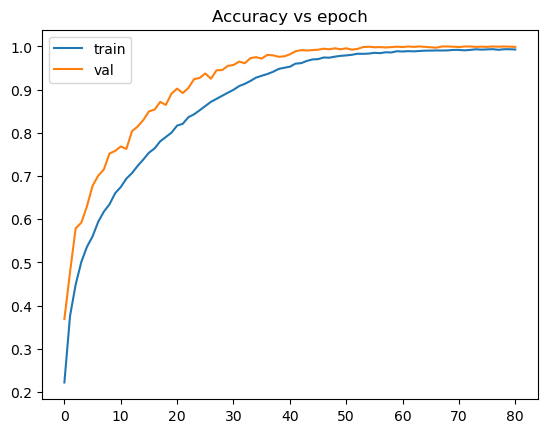

In [64]:
import matplotlib.pyplot as plt

# To make good visualizations, you need to make sure that you are keeping track of your loss in a train_loss_dict
plt.figure()
sns.lineplot(train_accuracies, label="train")
sns.lineplot(val_accuracies, label= "val")
plt.title("Accuracy vs epoch")
plt.show()


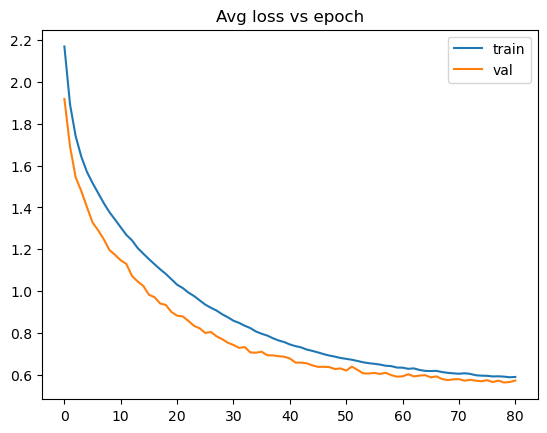

In [65]:

plt.figure()
sns.lineplot(train_losses, label="train")
sns.lineplot(val_losses, label= "val")
plt.title("Avg loss vs epoch")
plt.show()


# Part 3: DINO w/ a downstream classifier

This section has largely the same goal as Part 2, except that you will be using DINO embeddings instead of CLIP embeddings.

Recall from lecture that though DINO and CLIP are both self-supervised, foundational vision models, they are trained differently and thus have different strengths and weaknesses. It might be useful to keep these differences in mind as you train your downstream classifier and compare the results to Part 2.

We will be using [DINOv2](https://huggingface.co/docs/transformers/en/model_doc/dinov2) for this part.

**IMPORTANT**
* though you can (and should, where applicable) reuse code from part 2, make sure to use **new** variables and not overwrite the variables you used in part 2.
* if you run out of GPU memory, you can consider putting the model from previous sections on CPU temporarily

### Loading DINOv2

In [66]:
from transformers import AutoImageProcessor, AutoModel

# Loading DINOv2
print("Loading DINOv2 Base...")
dino_model = AutoModel.from_pretrained("facebook/dinov2-base")
dino_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
print("DINOv2 Base loaded successfully.")

# Freeze the DINO model
dino_model.eval()
for param in dino_model.parameters():
    param.requires_grad = False

Loading DINOv2 Base...


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

c:\Users\golfp\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\golfp\.cache\huggingface\hub\models--facebook--dinov2-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


DINOv2 Base loaded successfully.


### Now let's write a downstream classifier.
You can reuse your classifier **architecture** from Part 2, but note that DINOv2-base produces different size embeddings than CLIP (How can you account for this in the model?)

**Important: Instantiate a new, separate classifier here -- do not reuse variables from Part 2.**

In [ ]:
# TODO: Instantiate a new classifier for DINO features (separate from Part 2).


## Train your model.
Same instructions as Part 2: experiment with hyperparameters and log your training loss. The demo loop below shows how to extract DINOv2 features.

Note that we use `outputs.last_hidden_state[:, 0, :]` to get the [CLS] token embedding, since DINO does not expose a `get_image_features` API like CLIP does.

Also, once again, you can reuse code from part 2, make sure to use **new** variables and not overwrite the variables you used in part 2.

In [ ]:
# TODO: Set up your optimizer and loss tracking (separate from Part 2).
# Reuse your Part 2 approach, pointing at your new classifier.

In [ ]:
# Demo training loop for DINOv2 features.
# DINOv2 does NOT have get_image_features() like CLIP.
# Instead, we extract the CLS token from last_hidden_state.

for epoch in range(1):
    for images, labels in train_loader:

        optimizer.zero_grad()

        # get image embeddings through the frozen foundation model
        with torch.no_grad():
            outputs = dino_model(pixel_values=images)
            embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token (768-dim)

        preds = qwen_model(embeddings)
        loss = criterion(preds.squeeze(), labels)

        train_loss_dict[epoch] = loss.item()

        loss.backward()
        optimizer.step()

## Validate your model.

In [ ]:
# TODO: Validate your DINO classifier (reuse Part 2 approach).
# Extract features using dino_model and last_hidden_state[:, 0, :] instead of clip_model.get_image_features().

## Visualize Results.
Compare your DINO classifier's performance against your CLIP classifier from Part 2.

In [ ]:
# TODO: Visualize your DINO training results and compare with Part 2.

# Part 4: Auto-regressive VLM Zero-Shot evaluation

### Note: This section is **optional** for **5% extra credit** on the project.

Auto-regressive VLMs, pre-trained on internet-scale language and text data, offer a different paradigm of vision-language modeling compared to CLIP and DINO. Instead of learning a joint embedding space for images and text, these models are trained to **generate text** based on both visual and textual input.

In the context of this project, this means that instead of either accessing the model's embeddings (Part 1) or training a downstream classifier (Part 2) on top of the model, we can directly query the model with a prompt that includes both an image and a question, and have the model generate an answer.

#### Qwen2.5-VL-3B-Instruct

We will be working with the [Qwen2.5-VL-3B-Instruct](https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct) model for this part of the project.

VL stands for "vision-language", and it means that this model is trained to take in both images and text as input.

Note that this model is also marked as "Instruct", which means it’s been instruction-tuned through various learning methods to follow prompts and answer questions, when prompted correctly. In practice, this means that we can expect the model to generate useful and relevant answers to our prompts (to a reasonable limit - this model is only 3B parameters, which puts it at roughly at the order of 1/1000x the size of LLMs you might be used to interacting with, like ChatGPT / Claude / Gemini).

#### Hugging Face

We've been using Hugging Face for our own model checkpoints and for CLIP / DINO models, but Hugging Face also has a lot of auto-regressive LLMs available, including Qwen2.5-VL-3B-Instruct.

Hugging Face is a great resource for finding and using pre-trained models, because they (1) keep the various parts of an LLM including the weights, config, tokenizer, and chat template in one place (2) provide a standardized interface for many LLMs, even though they may have different architectures, and (3) have a lot of documentation and tutorials to help you get started. We will particularly see the advantage of this abstraction below.


**Same as Part 3:** if you run out of GPU memory, you can consider putting the model from previous sections on CPU temporarily. Also, make sure to use new variables and not overwrite the variables you used in part 2 or part 3.

### Loading the model and passing a sample query

The example below is taken from the Hugging Face page for the model:

In [ ]:
# Load model directly
from transformers import AutoProcessor, AutoModelForImageTextToText

qwen_symbol = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")
qwen_model = AutoModelForImageTextToText.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/p-blog/candy.JPG"},
            {"type": "text", "text": "What animal is on the candy?"}
        ]
    },
]
inputs = qwen_symbol.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(qwen_model.device)

outputs = qwen_model.generate(**inputs, max_new_tokens=40)
print(qwen_symbol.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

Before moving forward, make sure you understand what the code above is doing. In particular, it is important to understand:
- the difference between the `processor` and the `model` -- what does each one do?
- how (and why) the prompt is being structured:
    - what is the purpose of the "user" role?
    - how is the image being included in the prompt?
    - how is the text question being included in the prompt?
    - note the data structure of the prompt -- it's a list of dictionaries, where each dictionary has a "role" and "content" key (where content itself is a list of dictionaries).
- what is happening in `apply_chat_template`? What do the parameters mean?
- what is the type of `inputs` and `outputs`?
- how do we extract the generated text answer from `outputs`?

Here are some good resources (documentation) to help you answer these:

- Transformers task guide (VLM inference): Image-text-to-text
  https://huggingface.co/docs/transformers/en/tasks/image_text_to_text

- Chat templates in Transformers (`messages` format, roles, `apply_chat_template`, `add_generation_prompt`) https://huggingface.co/docs/transformers/en/chat_templating

- Multimodal chat templating (how images/videos are represented in `content`, and how processors build tensors) https://huggingface.co/docs/transformers/en/chat_templating_multimodal

- Processors (what a “processor” is; tokenizer + image processor; how it differs from the model) https://huggingface.co/docs/transformers/en/main_classes/processors

- Auto classes (`AutoProcessor`, `AutoModel*`, what `from_pretrained()` loads)  https://huggingface.co/docs/transformers/en/model_doc/auto

- Model outputs https://huggingface.co/docs/transformers/en/main_classes/output

- Generation docs (`generate()`, what it returns parameters like `max_new_tokens`) https://huggingface.co/docs/transformers/en/main_classes/text_generation  

- Tokenizer decode https://huggingface.co/docs/transformers/main_classes/tokenizer


### Zero-shot classification

The code below gives a skeleton for how you might use Qwen to do zero-shot classification on our adversarial MNIST dataset.

(Note the similarities and differences vs CLIP zero-shot classification)

You might have to change the batch size or the way the dataloader is structured to fit the input requirements of the model.

Things to consider:
- The prompt: prompt engineering is a huge part of getting useful results from auto-regressive LLMs. How can you leverage your knolwedge of the dataset to write a strong prompt that will frequently elicit the correct answer from the model? Remember that the model has been instruction-tuned, so it should be able to follow instructions well, but you still have to give it the right instructions! You can keep iterating on your prompt based on failiure cases

- Extracting the answer: The model will generate text, but how do you extract the class label from the generated text? You might have to do some string parsing, or you might be able to engineer your prompt in a way that makes it easy to extract the answer.

- Constructing the message: Recall the chat template and message structure that the model expects. Remember that the instruction tuning is only promised to work if you follow the expected structure, so make sure to understand the expected structure and follow it as closely as possible.



In [ ]:
correct, total = 0, 0

prompt = "" # Fill in. Remember, Qwen2.5-VL-3B-Instruct is an instruction-tuned model, so it will be sensitive to your instructions.

for epoch in range(1):
    for images, labels in train_loader:

        with torch.no_grad():

            message = None # Construct a message in the format shown in the demo above, using the images and the prompt you just defined.

            preds = None # Get the model's predictions for this batch.

        correct += (preds == labels).sum().item()
        total += labels.numel()

print(f"zero-shot acc: {correct/total:.4f} ({correct}/{total})")

## Visualize results

In [ ]:
# TODO: Visualize where your model is succeeding and failing, and compare with the previous models